In [1]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta

def fetch_bitcoin_data():
    ticker = "BTC-USD"
    end_date = datetime.now()
    start_date = end_date - timedelta(days=4*365)

    print(f"Initiating download for {ticker}...")
    print(f"Timeframe: {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")

    btc_raw_data = yf.download(ticker, start=start_date, end=end_date)

    btc_raw_filtered = btc_raw_data[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
    
    if isinstance(btc_raw_filtered.columns, pd.MultiIndex):
        btc_raw_filtered.columns = btc_raw_filtered.columns.droplevel(1)

    btc_raw_filtered.index = btc_raw_filtered.index.tz_localize(None)

    print("\n--- Download Complete. Data Preview ---")
    print(btc_raw_filtered.head())
    print("\n---------------------------------------")

    filename = "btc_financials_4yr.csv"
    btc_raw_filtered.to_csv(filename)
    print(f"Success: Dataset saved locally as '{filename}'")

if __name__ == "__main__":
    fetch_bitcoin_data()

Initiating download for BTC-USD...
Timeframe: 2022-04-28 to 2026-04-27


[*********************100%***********************]  1 of 1 completed


--- Download Complete. Data Preview ---
Price               Open          High           Low         Close  \
Date                                                                 
2022-04-28  39241.429688  40269.464844  38941.421875  39773.828125   
2022-04-29  39768.617188  39887.269531  38235.535156  38609.824219   
2022-04-30  38605.859375  38771.210938  37697.941406  37714.875000   
2022-05-01  37713.265625  38627.859375  37585.789062  38469.093750   
2022-05-02  38472.187500  39074.972656  38156.562500  38529.328125   

Price            Volume  
Date                     
2022-04-28  33903704907  
2022-04-29  30882994649  
2022-04-30  23895713731  
2022-05-01  27002760110  
2022-05-02  32922642426  

---------------------------------------
Success: Dataset saved locally as 'btc_financials_4yr.csv'


In [2]:
import requests
import pandas as pd

def fetch_fng_data():
    url = "https://api.alternative.me/fng/?limit=1500"
    response = requests.get(url)
    fng_data = response.json()['data']
    
    fng_df = pd.DataFrame(fng_data)
    
    fng_df['Date'] = pd.to_datetime(pd.to_numeric(fng_df['timestamp']), unit='s').dt.date
    fng_df['fng_value'] = fng_df['value'].astype(int)
    
    fng_df = fng_df[['Date', 'fng_value', 'value_classification']]
    fng_df = fng_df.sort_values('Date').reset_index(drop=True)
    
    print("\n--- Fear & Greed Data Preview ---")
    print(fng_df.head())
    print("\n---------------------------------")
    
    filename = "fng_index_4yr.csv"
    fng_df.to_csv(filename, index=False)
    print(f"Success: Dataset saved locally as '{filename}'")

if __name__ == "__main__":
    fetch_fng_data()


--- Fear & Greed Data Preview ---
         Date  fng_value value_classification
0  2018-02-01         30                 Fear
1  2018-02-02         15         Extreme Fear
2  2018-02-03         40                 Fear
3  2018-02-04         24         Extreme Fear
4  2018-02-05         11         Extreme Fear

---------------------------------
Success: Dataset saved locally as 'fng_index_4yr.csv'


In [6]:
import pandas as pd
import requests
import io

def fetch_gdelt_sentiment():
    """
    Fetches daily average media sentiment (Tone) for 'Bitcoin' 
    from the GDELT 2.0 API and saves it to a CSV.
    """
    # 1. Define the GDELT API endpoint and parameters
    # 'timelinetone' mode calculates the average daily sentiment score.
    url = "https://api.gdeltproject.org/api/v2/doc/doc"
    params = {
        "query": "bitcoin",
        "mode": "timelinetone",
        "format": "csv",
        "timespan": "2y" # Aligning with our 2-year yfinance timeframe
    }

    print("Querying the GDELT database for global news sentiment...")
    
    # 2. Make the HTTP request to the API
    response = requests.get(url, params=params)
    
    if response.status_code != 200:
        print(f"Error fetching data: HTTP {response.status_code}")
        return
        
    # 3. Read the CSV response directly into a Pandas DataFrame
    # The API returns raw CSV text, which we parse using io.StringIO
    gdelt_raw = pd.read_csv(io.StringIO(response.text))
    
    # 4. Scrub: Clean and align the data for our future Random Forest model
    # GDELT returns a 'Date' column and a 'Series' column (which is the tone)
    gdelt_clean = gdelt_raw.rename(columns={"Series": "Global_Sentiment_Tone"})
    
    # Convert the GDELT date format to match our yfinance data (YYYY-MM-DD)
    # This is a critical scrubbing step to ensure we can merge the datasets later!
    gdelt_clean['Date'] = pd.to_datetime(gdelt_clean['Date']).dt.date
    gdelt_clean.set_index('Date', inplace=True)

    # 5. Preview the structured data
    print("\n--- Download Complete. Data Preview ---")
    print(gdelt_clean.head())
    print("\n---------------------------------------")
    
    # 6. Export to CSV for the next stage of the pipeline
    filename = "btc_gdelt_sentiment_2yr.csv"
    gdelt_clean.to_csv(filename)
    print(f"Success: Dataset saved locally as '{filename}'")

# Execute the function
if __name__ == "__main__":
    fetch_gdelt_sentiment()

Querying the GDELT database for global news sentiment...

--- Download Complete. Data Preview ---
           Global_Sentiment_Tone   Value
Date                                    
2024-04-28          Average Tone  0.8445
2024-04-29          Average Tone  0.5105
2024-04-30          Average Tone -0.2752
2024-05-01          Average Tone -1.4080
2024-05-02          Average Tone  0.1094

---------------------------------------
Success: Dataset saved locally as 'btc_gdelt_sentiment_2yr.csv'


In [4]:
import pandas as pd
import requests
import io
import time

def fetch_gdelt_sentiment_2022_to_2024():
    """
    Fetches daily average media sentiment (Tone) for 'Bitcoin' 
    from the GDELT 2.0 API specifically from April 26, 2022 to April 26, 2024.
    """
    url = "https://api.gdeltproject.org/api/v2/doc/doc"
    
    # 1. Define exact start and end dates in GDELT format (YYYYMMDDHHMMSS)
    params = {
        "query": "bitcoin",
        "mode": "timelinetone",
        "format": "csv",
        "STARTDATETIME": "20220426000000",
        "ENDDATETIME": "20240426235959"
    }

    # 2. Add headers to prevent the server from rejecting the connection
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }

    max_retries = 3
    
    for attempt in range(max_retries):
        try:
            print(f"Querying the GDELT database for 2022-2024 data... (Attempt {attempt + 1}/{max_retries})")
            response = requests.get(url, params=params, headers=headers, timeout=20)
            
            if response.status_code == 200:
                # 3. Read the CSV response directly into a Pandas DataFrame
                gdelt_raw = pd.read_csv(io.StringIO(response.text))
                
                # 4. Scrub: Clean and align the data
                gdelt_clean = gdelt_raw.rename(columns={"Series": "Global_Sentiment_Tone"})
                gdelt_clean['Date'] = pd.to_datetime(gdelt_clean['Date']).dt.date
                gdelt_clean.set_index('Date', inplace=True)
                
                # 5. Preview the structured data
                print("\n--- Download Complete. Data Preview ---")
                print(gdelt_clean.head())
                print("\n---------------------------------------")
                
                # 6. Export to CSV 
                filename = "btc_gdelt_sentiment_older_2yr.csv"
                gdelt_clean.to_csv(filename)
                print(f"Success: Dataset saved locally as '{filename}'")
                return
                
            else:
                print(f"Error fetching data: HTTP {response.status_code}")
                time.sleep(5)
                
        except requests.exceptions.RequestException as e:
            print(f"Connection dropped: {e}")
            print("Retrying in 5 seconds...")
            time.sleep(5)
            
    print("Failed to retrieve data after multiple attempts.")

# Execute the function
if __name__ == "__main__":
    fetch_gdelt_sentiment_2022_to_2024()

Querying the GDELT database for 2022-2024 data... (Attempt 1/3)

--- Download Complete. Data Preview ---
           Global_Sentiment_Tone   Value
Date                                    
2022-04-26          Average Tone -0.0012
2022-04-27          Average Tone -0.4567
2022-04-28          Average Tone -0.6723
2022-04-29          Average Tone -0.1001
2022-04-30          Average Tone -0.2227

---------------------------------------
Success: Dataset saved locally as 'btc_gdelt_sentiment_older_2yr.csv'


In [9]:
import pandas as pd

def merge_gdelt_data():
    df_recent = pd.read_csv("btc_gdelt_sentiment_2yr.csv")
    df_older = pd.read_csv("btc_gdelt_sentiment_older_2yr.csv")
    
    df_combined = pd.concat([df_older, df_recent])
    
    df_combined = df_combined.drop_duplicates(subset=['Date'])
    
    df_combined['Date'] = pd.to_datetime(df_combined['Date'])
    df_combined = df_combined.sort_values('Date').reset_index(drop=True)
    
    print("\n--- Final Merged Data Preview ---")
    print(df_combined.head())
    print("...")
    print(df_combined.tail())
    print(f"\nTotal rows: {len(df_combined)}")
    print("---------------------------------")
    
    filename = "gdelt_tone_4yr.csv"
    df_combined.to_csv(filename, index=False)
    print(f"Success: Combined dataset saved locally as '{filename}'")

if __name__ == "__main__":
    merge_gdelt_data()


--- Final Merged Data Preview ---
        Date Global_Sentiment_Tone   Value
0 2022-04-26          Average Tone -0.0012
1 2022-04-27          Average Tone -0.4567
2 2022-04-28          Average Tone -0.6723
3 2022-04-29          Average Tone -0.1001
4 2022-04-30          Average Tone -0.2227
...
           Date Global_Sentiment_Tone   Value
1439 2026-04-23          Average Tone -0.6982
1440 2026-04-24          Average Tone -0.6834
1441 2026-04-25          Average Tone -0.8100
1442 2026-04-26          Average Tone  0.4329
1443 2026-04-27          Average Tone -0.6473

Total rows: 1444
---------------------------------
Success: Combined dataset saved locally as 'gdelt_tone_4yr.csv'


In [64]:
import requests
import pandas as pd
from datetime import datetime, timedelta
import time

def fetch_binance_funding_rate():
    symbol = "BTCUSDT"
    end_date = datetime.now()
    start_date = end_date - timedelta(days=4*365)
    
    start_time_ms = int(start_date.timestamp() * 1000)
    end_time_ms = int(end_date.timestamp() * 1000)
    
    all_data = []
    current_start = start_time_ms
    
    print(f"Fetching Binance funding rates for {symbol} from {start_date.date()} to {end_date.date()}...")
    
    while current_start < end_time_ms:
        url = "https://fapi.binance.com/fapi/v1/fundingRate"
        params = {
            "symbol": symbol,
            "startTime": current_start,
            "endTime": end_time_ms,
            "limit": 1000
        }
        
        response = requests.get(url, params=params)
        
        if response.status_code != 200:
            print(f"Error fetching data: HTTP {response.status_code}")
            break
            
        data = response.json()
        if not data:
            break
            
        all_data.extend(data)
        last_time = data[-1]['fundingTime']
        current_start = last_time + 1
        time.sleep(0.5)
        
    if all_data:
        df = pd.DataFrame(all_data)
        df['fundingRate'] = df['fundingRate'].astype(float)
        df['Date'] = pd.to_datetime(df['fundingTime'], unit='ms').dt.date
        
        daily_df = df.groupby('Date')['fundingRate'].mean().reset_index()
        daily_df = daily_df.rename(columns={'fundingRate': 'Funding_Rate'})
        daily_df = daily_df.sort_values('Date').reset_index(drop=True)
        
        print("\n--- Binance Daily Funding Rate Preview ---")
        print(daily_df.head())
        print("...")
        print(daily_df.tail())
        print(f"\nTotal daily rows: {len(daily_df)}")
        
        filename = "binance_funding_4yr.csv"
        daily_df.to_csv(filename, index=False)
        print(f"Success: Dataset saved locally as '{filename}'")

if __name__ == "__main__":
    fetch_binance_funding_rate()

Fetching Binance funding rates for BTCUSDT from 2022-04-28 to 2026-04-27...

--- Binance Daily Funding Rate Preview ---
         Date  Funding_Rate
0  2022-04-28      0.000022
1  2022-04-29      0.000075
2  2022-04-30      0.000004
3  2022-05-01      0.000042
4  2022-05-02      0.000097
...
            Date  Funding_Rate
1456  2026-04-23     -0.000060
1457  2026-04-24     -0.000049
1458  2026-04-25     -0.000043
1459  2026-04-26      0.000002
1460  2026-04-27      0.000002

Total daily rows: 1461
Success: Dataset saved locally as 'binance_funding_4yr.csv'


In [12]:
import pandas as pd
import numpy as np

btc_df = pd.read_csv('btc_financials_4yr.csv')
gdelt_df = pd.read_csv('gdelt_tone_4yr.csv')
funding_df = pd.read_csv('binance_funding_4yr.csv')
fng_df = pd.read_csv('fng_index_4yr.csv')

for df in [btc_df, gdelt_df, funding_df, fng_df]:
    df['Date'] = pd.to_datetime(df['Date']).dt.date

gdelt_df.rename(columns={'Value': 'GDELT_Tone'}, inplace=True)

master_df = btc_df.merge(fng_df[['Date', 'fng_value']], on='Date', how='inner')
master_df = master_df.merge(gdelt_df[['Date', 'GDELT_Tone']], on='Date', how='inner')
master_df = master_df.merge(funding_df[['Date', 'Funding_Rate']], on='Date', how='inner')

master_df = master_df.sort_values('Date').reset_index(drop=True)

master_df['Future_15d_Min'] = master_df['Close'].rolling(window=15).min().shift(-15)
master_df['Max_Drop_Percent'] = (master_df['Future_15d_Min'] - master_df['Close']) / master_df['Close']
master_df['Target_Crash'] = (master_df['Max_Drop_Percent'] <= -0.10).astype(int)

master_df_clean = master_df.dropna().copy()

master_df_clean.to_csv('phase1_master_dataset.csv', index=False)

print("--- Master Dataset Head ---")
print(master_df_clean[['Date', 'Close', 'Future_15d_Min', 'Max_Drop_Percent', 'Target_Crash']].head(10))
print("\n--- Crash Target Distribution ---")
print(master_df_clean['Target_Crash'].value_counts())

--- Master Dataset Head ---
         Date         Close  Future_15d_Min  Max_Drop_Percent  Target_Crash
0  2022-04-28  39773.828125    28936.355469         -0.272477             1
1  2022-04-29  38609.824219    28936.355469         -0.250544             1
2  2022-04-30  37714.875000    28936.355469         -0.232760             1
3  2022-05-01  38469.093750    28936.355469         -0.247803             1
4  2022-05-02  38529.328125    28936.355469         -0.248978             1
5  2022-05-03  37750.453125    28720.271484         -0.239207             1
6  2022-05-04  39698.371094    28720.271484         -0.276538             1
7  2022-05-05  36575.140625    28720.271484         -0.214760             1
8  2022-05-06  36040.921875    28720.271484         -0.203121             1
9  2022-05-07  35501.953125    28720.271484         -0.191023             1

--- Crash Target Distribution ---
Target_Crash
0    1195
1     231
Name: count, dtype: int64


In [13]:
import pandas as pd
import numpy as np

# 1. Load the Phase 1 dataset
df = pd.read_csv('phase1_master_dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"Starting shape: {df.shape}")

# ==========================================
# FEATURE GROUP A: Technical Momentum & Volatility
# ==========================================

# 1. Moving Averages (Trend direction)
df['SMA_7'] = df['Close'].rolling(window=7).mean()
df['SMA_14'] = df['Close'].rolling(window=14).mean()

# 2. Volume Profile (Is buying/selling accelerating?)
df['Volume_Ratio_7d'] = df['Volume'] / df['Volume'].rolling(window=7).mean()

# 3. Bollinger Bands (Measures volatility and "overbought" conditions)
df['BB_Middle'] = df['Close'].rolling(window=20).mean()
df['BB_Std'] = df['Close'].rolling(window=20).std()
df['BB_Upper'] = df['BB_Middle'] + (df['BB_Std'] * 2)
df['BB_Lower'] = df['BB_Middle'] - (df['BB_Std'] * 2)
# Distance from upper band (If price is > Upper Band, market is severely overheated)
df['BB_Width_Percent'] = (df['Close'] - df['BB_Middle']) / (df['BB_Upper'] - df['BB_Lower'])

# 4. RSI (Relative Strength Index) - Industry standard for overbought/oversold
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI_14'] = 100 - (100 / (1 + rs))

# ==========================================
# FEATURE GROUP B: Sentiment & Risk Divergence
# ==========================================

# 5. Sentiment Momentum (Is greed rising or falling?)
df['FNG_Momentum_3d'] = df['fng_value'] - df['fng_value'].shift(3)
df['FNG_Momentum_7d'] = df['fng_value'] - df['fng_value'].shift(7)

# 6. Macro News Tone Momentum (Are global headlines suddenly turning negative?)
df['GDELT_Tone_Momentum_3d'] = df['GDELT_Tone'] - df['GDELT_Tone'].shift(3)

# 7. Market Risk (Leverage/Funding Rate buildup)
# A sustained high funding rate over 7 days means extreme greed/leverage
df['Funding_Rate_7d_Avg'] = df['Funding_Rate'].rolling(window=7).mean()

# ==========================================
# CLEANUP & EXPORT
# ==========================================

# Drop rows with NaNs created by rolling windows (e.g., the first 20 days)
df_features = df.dropna().copy()

# Save the finalized, feature-rich dataset
df_features.to_csv('phase2_features_dataset.csv', index=False)

print(f"\nFinal Feature-Rich Shape: {df_features.shape}")
print("\n--- Engineered Features Preview ---")
features_to_show = ['Date', 'Close', 'RSI_14', 'BB_Width_Percent', 'FNG_Momentum_3d', 'Funding_Rate_7d_Avg', 'Target_Crash']
print(df_features[features_to_show].head(10))

Starting shape: (1426, 12)

Final Feature-Rich Shape: (1407, 25)

--- Engineered Features Preview ---
         Date         Close     RSI_14  BB_Width_Percent  FNG_Momentum_3d  \
19 2022-05-17  30425.857422  30.241958         -0.228544             -1.0   
20 2022-05-18  28720.271484  19.994371         -0.303284              2.0   
21 2022-05-19  30314.333984  31.326891         -0.183769             -1.0   
22 2022-05-20  29200.740234  30.280395         -0.231182              5.0   
23 2022-05-21  29432.226562  32.185718         -0.195919              1.0   
24 2022-05-22  30323.722656  38.669827         -0.116185              1.0   
25 2022-05-23  29098.910156  45.705149         -0.188356             -3.0   
26 2022-05-24  29655.585938  45.038087         -0.131235             -1.0   
27 2022-05-25  29562.361328  52.655982         -0.123541             -3.0   
28 2022-05-26  29267.224609  50.916871         -0.147027              2.0   

    Funding_Rate_7d_Avg  Target_Crash  
19        

 PHASE 3: AUTOMATED DIAGNOSTIC REPORT

1. CLASS IMBALANCE:
   - Normal Days (0): 84.36%
   - Crash Days  (1): 15.64%
   * Note: The dataset is highly imbalanced. We MUST use 'scale_pos_weight' in XGBoost.

2. MULTICOLLINEARITY ALERTS (Correlation > 0.85):
   - WARNING: 'SMA_7' and 'Close' are highly correlated (1.00).
   - WARNING: 'SMA_14' and 'Close' are highly correlated (1.00).
   - WARNING: 'SMA_14' and 'SMA_7' are highly correlated (1.00).


C:\Users\chank\AppData\Local\Temp\ipykernel_17288\1580129347.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Target_Crash', data=df_eda, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
C:\Users\chank\AppData\Local\Temp\ipykernel_17288\1580129347.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Normal (0)', 'Crash Imminent (1)'])
C:\Users\chank\AppData\Local\Temp\ipykernel_17288\1580129347.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target_Crash', y='RSI_14', data=df_eda, ax=axes[2], palette=['#2ecc71', '#e74c3c'])
C:\Users\chank\AppData\Local\Temp\ipykernel_17

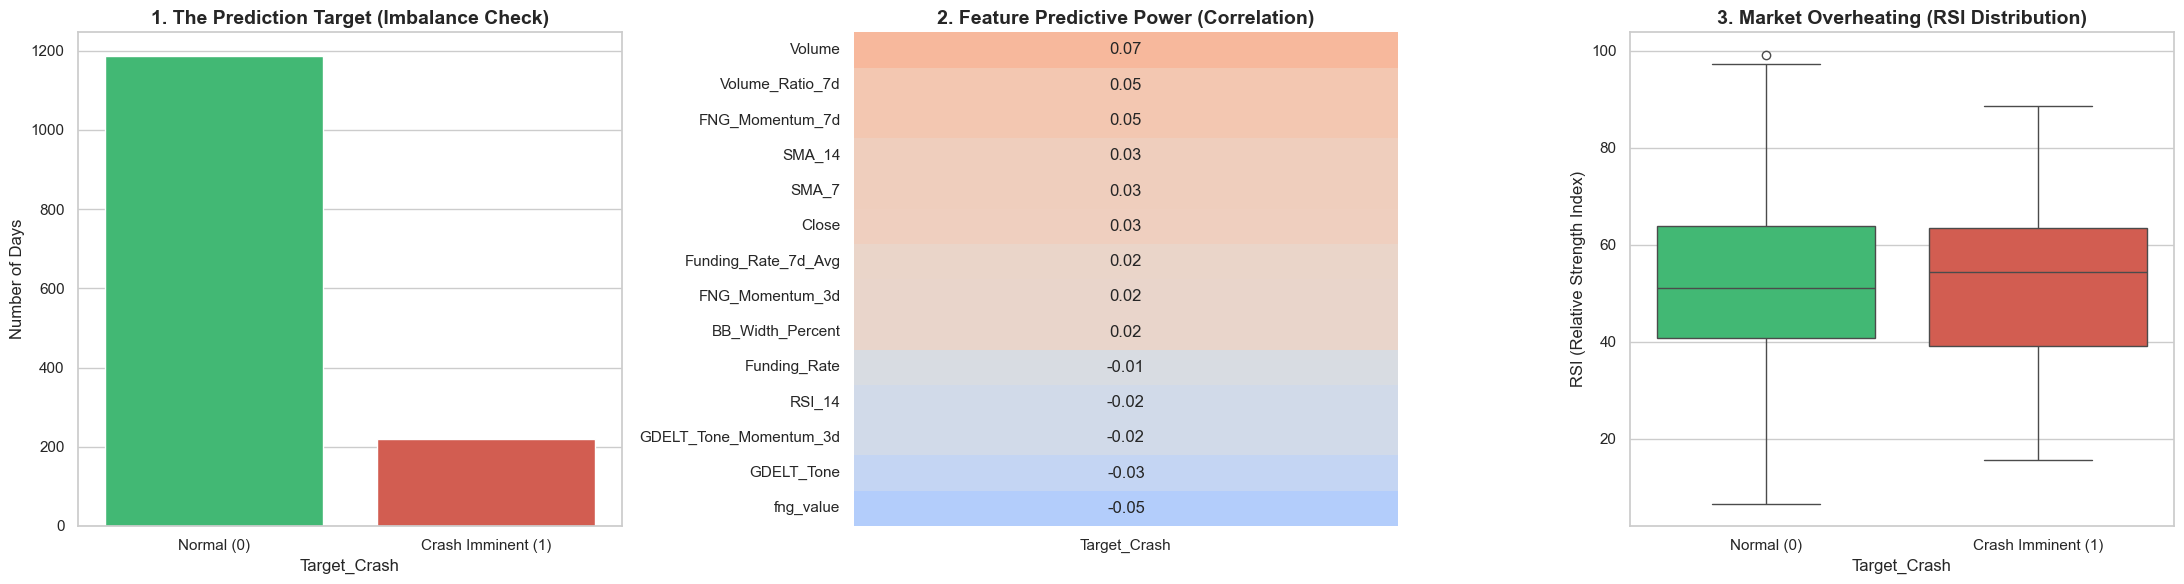


 Visual Dashboard saved as 'phase3_eda_dashboard.png'


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load the Phase 2 Dataset
df = pd.read_csv('phase2_features_dataset.csv')

# --- DEFINING OUR FEATURES ---
# CRITICAL: We must NOT include 'Future_15d_Min' or 'Max_Drop_Percent' in our features!
# These are "Target Leaks" (data from the future). If the model sees them, it will cheat.
features_to_analyze = [
    'Close', 'Volume', 'SMA_7', 'SMA_14', 'Volume_Ratio_7d', 
    'BB_Width_Percent', 'RSI_14', 'fng_value', 'FNG_Momentum_3d', 
    'FNG_Momentum_7d', 'GDELT_Tone', 'GDELT_Tone_Momentum_3d', 
    'Funding_Rate', 'Funding_Rate_7d_Avg', 'Target_Crash'
]

df_eda = df[features_to_analyze].copy()

# ==========================================
# DIAGNOSTIC REPORT (Text Output)
# ==========================================
print("==========================================")
print(" PHASE 3: AUTOMATED DIAGNOSTIC REPORT")
print("==========================================")

# A. Class Imbalance Check
crash_counts = df_eda['Target_Crash'].value_counts(normalize=True) * 100
print(f"\n1. CLASS IMBALANCE:")
print(f"   - Normal Days (0): {crash_counts[0]:.2f}%")
print(f"   - Crash Days  (1): {crash_counts[1]:.2f}%")
print("   * Note: The dataset is highly imbalanced. We MUST use 'scale_pos_weight' in XGBoost.")

# B. Multicollinearity Check (Finding redundant features)
print("\n2. MULTICOLLINEARITY ALERTS (Correlation > 0.85):")
corr_matrix = df_eda.corr()
collinearity_found = False
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            print(f"   - WARNING: '{corr_matrix.columns[i]}' and '{corr_matrix.columns[j]}' are highly correlated ({corr_matrix.iloc[i, j]:.2f}).")
            collinearity_found = True
if not collinearity_found:
    print("   - No extreme multicollinearity found. Features look distinct.")

# ==========================================
# VISUAL DASHBOARD
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Plot 1: The Target Imbalance
sns.countplot(x='Target_Crash', data=df_eda, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('1. The Prediction Target (Imbalance Check)', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['Normal (0)', 'Crash Imminent (1)'])
axes[0].set_ylabel('Number of Days')

# Plot 2: Correlation Heatmap (How features relate to the Target)
# We drop 'Target_Crash' from the y-axis to see how features correlate with EACH OTHER and the TARGET
corr_with_target = corr_matrix[['Target_Crash']].drop('Target_Crash').sort_values(by='Target_Crash', ascending=False)
sns.heatmap(corr_with_target, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1], vmin=-0.2, vmax=0.2, cbar=False)
axes[1].set_title('2. Feature Predictive Power (Correlation)', fontsize=14, fontweight='bold')

# Plot 3: Outlier Detection (RSI vs Target)
sns.boxplot(x='Target_Crash', y='RSI_14', data=df_eda, ax=axes[2], palette=['#2ecc71', '#e74c3c'])
axes[2].set_title('3. Market Overheating (RSI Distribution)', fontsize=14, fontweight='bold')
axes[2].set_xticklabels(['Normal (0)', 'Crash Imminent (1)'])
axes[2].set_ylabel('RSI (Relative Strength Index)')

plt.tight_layout()
plt.savefig("phase3_eda_dashboard.png", dpi=300)
plt.show()

print("\n==========================================")
print(" Visual Dashboard saved as 'phase3_eda_dashboard.png'")

In [16]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller

# Ensure your Phase 2 dataset is loaded
df = pd.read_csv('phase2_features_dataset.csv')

def check_stationarity(series, significance_level=0.05):
    # Drop NaNs to prevent ADF test errors
    clean_series = series.replace([np.inf, -np.inf], np.nan).dropna()
    result = adfuller(clean_series)
    p_value = result[1]
    is_stationary = p_value < significance_level
    return p_value, is_stationary

# Features to test
features_to_check = ['Close', 'Daily_Return', 'Volume', 'RSI_14', 'Funding_Rate']

print("--- Augmented Dickey-Fuller (ADF) Stationarity Test ---")
for feature in features_to_check:
    if feature in df.columns:
        p_val, stationary = check_stationarity(df[feature])
        status = "Stationary (Safe to use)" if stationary else "Non-Stationary (Consider differencing)"
        print(f"{feature: <15}: p-value = {p_val:.4f} | {status}")

--- Augmented Dickey-Fuller (ADF) Stationarity Test ---
Close          : p-value = 0.7246 | Non-Stationary (Consider differencing)
Volume         : p-value = 0.0112 | Stationary (Safe to use)
RSI_14         : p-value = 0.0000 | Stationary (Safe to use)
Funding_Rate   : p-value = 0.0000 | Stationary (Safe to use)


In [17]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import classification_report

# 1. Setup Data
df = pd.read_csv('phase2_features_dataset.csv')

# ADDED BACK: Calculate Daily Return before dropping NaNs
df['Daily_Return'] = df['Close'].pct_change()
df = df.dropna().reset_index(drop=True)

# ADDED BACK: 'Daily_Return' is now in the feature list
features = [
    'Daily_Return', 'Volume_Ratio_7d', 'BB_Width_Percent', 'RSI_14', 'fng_value', 
    'FNG_Momentum_3d', 'FNG_Momentum_7d', 'GDELT_Tone', 
    'GDELT_Tone_Momentum_3d', 'Funding_Rate', 'Funding_Rate_7d_Avg'
]
X = df[features]
y = df['Target_Crash']

# Initial chronological split for ultimate hold-out test
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

scale_pos_weight_value = (len(y_train) - sum(y_train)) / sum(y_train)

# 2. TimeSeriesSplit (Walk-Forward Validation)
tscv = TimeSeriesSplit(n_splits=5)

# 3. Parameter Grid setup
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200]
}

xgb_base = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight_value,
    random_state=42,
    eval_metric='logloss'
)

# 4. Grid Search Execution
print("Starting Grid Search with Walk-Forward Validation...")
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=tscv,          
    scoring='f1',     
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"\nBest Parameters Found: {grid_search.best_params_}")

# 5. Evaluate the best model on the hold-out test set
# RENAMED to xgb_model so it connects perfectly with your Ensemble cell
xgb_model = grid_search.best_estimator_ 
y_pred = xgb_model.predict(X_test)

print("\n--- Final Test Set Evaluation ---")
print(classification_report(y_test, y_pred))

Starting Grid Search with Walk-Forward Validation...

Best Parameters Found: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}

--- Final Test Set Evaluation ---
              precision    recall  f1-score   support

           0       0.83      0.68      0.75       229
           1       0.23      0.42      0.30        53

    accuracy                           0.63       282
   macro avg       0.53      0.55      0.52       282
weighted avg       0.72      0.63      0.66       282



In [18]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df[features])

def create_sequences(data, target, seq_length=15):
    X_seq = []
    y_seq = []
    for i in range(len(data) - seq_length):
        X_seq.append(data[i:(i + seq_length)])
        y_seq.append(target.iloc[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

X_lstm, y_lstm = create_sequences(scaled_features, df['Target_Crash'])

split_idx_lstm = int(len(X_lstm) * 0.8)
X_train_lstm = X_lstm[:split_idx_lstm]
X_test_lstm = X_lstm[split_idx_lstm:]
y_train_lstm = y_lstm[:split_idx_lstm]
y_test_lstm = y_lstm[split_idx_lstm:]

In [19]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df[features])

def create_sequences(data, target, seq_length=15):
    X_seq = []
    y_seq = []
    for i in range(len(data) - seq_length):
        X_seq.append(data[i:(i + seq_length)])
        y_seq.append(target.iloc[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

X_lstm, y_lstm = create_sequences(scaled_features, df['Target_Crash'])

split_idx_lstm = int(len(X_lstm) * 0.8)
X_train_lstm = X_lstm[:split_idx_lstm]
X_test_lstm = X_lstm[split_idx_lstm:]
y_train_lstm = y_lstm[:split_idx_lstm]
y_test_lstm = y_lstm[split_idx_lstm:]

In [20]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import classification_report

# 1. Define the Class Weights (Keras requires a dictionary format)
neg_count = len(y_train_lstm) - sum(y_train_lstm)
pos_count = sum(y_train_lstm)
keras_class_weights = {0: 1.0, 1: (neg_count / pos_count)}

# 2. Build the LSTM Architecture
lstm_model = Sequential()

# The LSTM Layer: It reads the 15-day sequences and has 50 internal "memory cells"
lstm_model.add(LSTM(units=50, return_sequences=False, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))

# The Dropout Layer: This prevents "overfitting" by randomly turning off 20% of the network during training
lstm_model.add(Dropout(0.2))

# The Output Layer: 1 single neuron that outputs a probability (between 0 and 1)
lstm_model.add(Dense(units=1, activation='sigmoid'))

# 3. Compile the Model
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4. Train the Model
print("Training the LSTM Model (This will take a few seconds)...")
history = lstm_model.fit(
    X_train_lstm, y_train_lstm, 
    epochs=30,               # The model will read through the dataset 30 times
    batch_size=32,           # It will look at 32 sequences at a time
    validation_split=0.1,    # It reserves 10% of training data to test itself after every epoch
    class_weight=keras_class_weights,
    verbose=1
)

# 5. Evaluate the Model
print("\nGenerating Predictions on Unseen Test Data...")
y_pred_prob = lstm_model.predict(X_test_lstm)

# Convert the raw probability (e.g., 0.85) into a strict 1 (Crash) or 0 (Normal)
y_pred_lstm = (y_pred_prob > 0.5).astype(int)

# 6. Print the Results
print("\n--- Tier 2: LSTM Classification Report ---")
print(classification_report(y_test_lstm, y_pred_lstm))

Training the LSTM Model (This will take a few seconds)...
Epoch 1/30


C:\Users\chank\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.3340 - loss: 1.2185 - val_accuracy: 0.0714 - val_loss: 0.7254
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4630 - loss: 1.2135 - val_accuracy: 0.0714 - val_loss: 0.8232
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4970 - loss: 1.2053 - val_accuracy: 0.0714 - val_loss: 0.7665
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2840 - loss: 1.2109 - val_accuracy: 0.0714 - val_loss: 0.7753
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4160 - loss: 1.1888 - val_accuracy: 0.6071 - val_loss: 0.6696
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4320 - loss: 1.1807 - val_accuracy: 0.7143 - val_loss: 0.5333
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5110 - loss: 1.1880 - val_accuracy: 0.5446 - val_loss: 0.6614
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5010 - loss: 1.1403 - val_accuracy: 0.6071 - val_loss: 0.5960
Ep

In [73]:
import numpy as np
from sklearn.metrics import classification_report

y_pred_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_prob_lstm = lstm_model.predict(X_test_lstm).flatten()

min_len = min(len(y_pred_prob_xgb), len(y_pred_prob_lstm))

xgb_probs_aligned = y_pred_prob_xgb[-min_len:]
lstm_probs_aligned = y_pred_prob_lstm[-min_len:]
y_test_aligned = y_test.values[-min_len:]

ensemble_probs = (xgb_probs_aligned + lstm_probs_aligned) / 2.0
ensemble_preds = (ensemble_probs > 0.5).astype(int)

print(classification_report(y_test_aligned, ensemble_preds))

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
              precision    recall  f1-score   support

           0       0.95      0.44      0.60       226
           1       0.28      0.91      0.42        53

    accuracy                           0.53       279
   macro avg       0.61      0.67      0.51       279
weighted avg       0.82      0.53      0.57       279



In [74]:
pip install arch

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [75]:
import pandas as pd
import numpy as np
from arch import arch_model
from sklearn.metrics import classification_report

df = pd.read_csv('phase2_features_dataset.csv')
df['Daily_Return_Pct'] = df['Close'].pct_change() * 100
df = df.dropna().reset_index(drop=True)

returns = df['Daily_Return_Pct'].values
split_idx = int(len(returns) * 0.8)

test_returns = returns[split_idx:]
rolling_forecasts = []

for i in range(len(test_returns)):
    temp_returns = returns[:split_idx + i]
    am = arch_model(temp_returns, vol='Garch', p=1, q=1, rescale=False)
    res = am.fit(disp='off')
    pred = res.forecast(horizon=1, reindex=False)
    rolling_forecasts.append(np.sqrt(pred.variance.values[-1, 0]))

volatility_preds = np.array(rolling_forecasts)

vol_threshold = np.percentile(volatility_preds, 75)
garch_flags = (volatility_preds > vol_threshold).astype(int)

min_len = min(len(ensemble_preds), len(garch_flags))
final_alerts = (ensemble_preds[-min_len:] & garch_flags[-min_len:])

print(classification_report(y_test_aligned[-min_len:], final_alerts))

              precision    recall  f1-score   support

           0       0.83      0.84      0.83       226
           1       0.27      0.25      0.25        53

    accuracy                           0.73       279
   macro avg       0.55      0.54      0.54       279
weighted avg       0.72      0.73      0.72       279



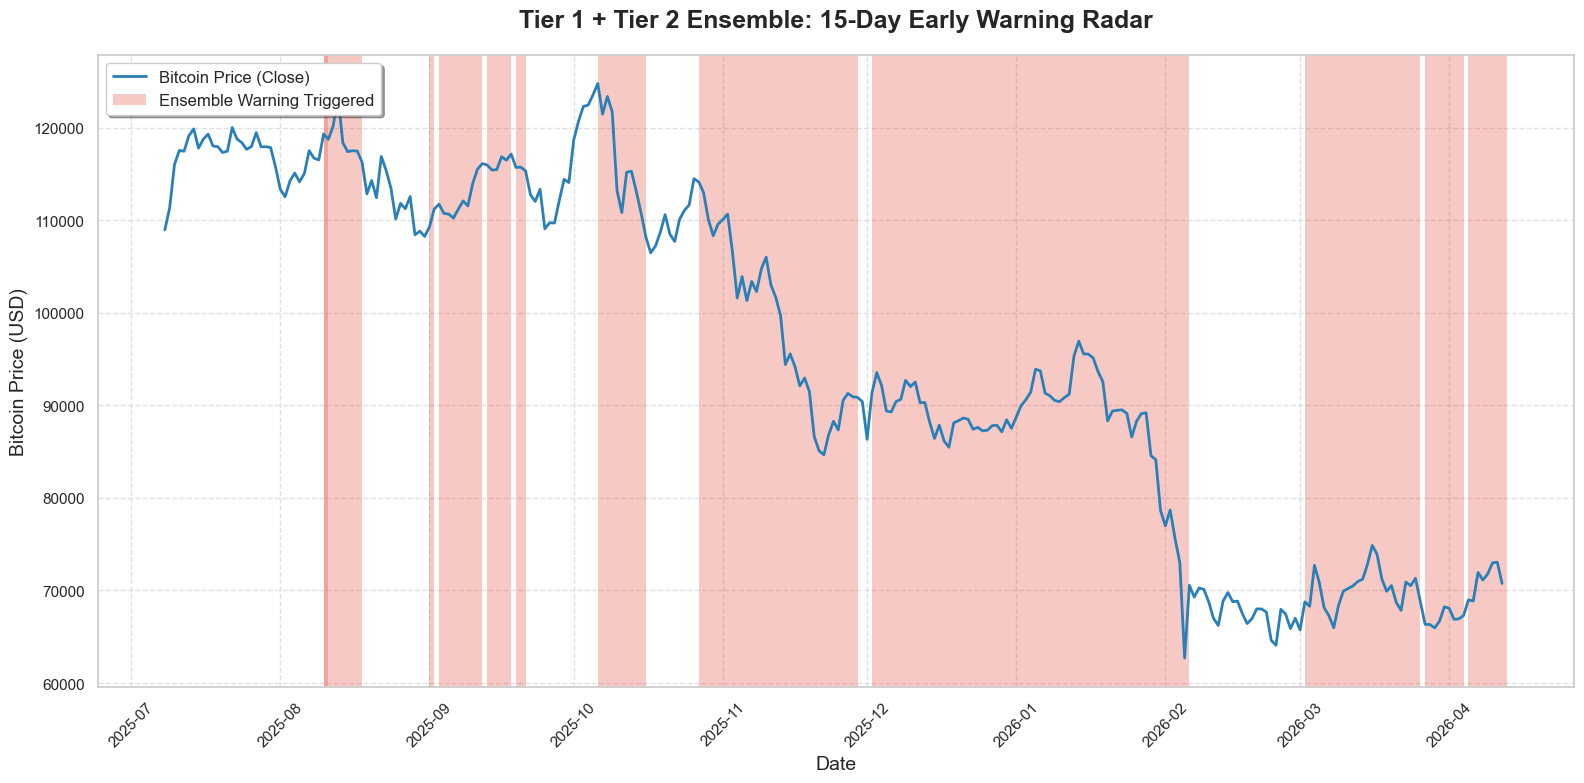


Success: Temporal Overlay Chart generated and saved as 'phase5_temporal_overlay.png'


In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Retrieve the dates and prices for the exact test period
# Our ensemble predictions correspond to the last 'min_len' rows of our dataset
df_full = pd.read_csv('phase2_features_dataset.csv')
df_full['Date'] = pd.to_datetime(df_full['Date'])

# Get the chronological slice that matches our test data length
test_dates = df_full['Date'].values[-min_len:]
test_prices = df_full['Close'].values[-min_len:]

# 2. Create the Figure
plt.figure(figsize=(16, 8))
plt.plot(test_dates, test_prices, color='#2980b9', linewidth=2, label='Bitcoin Price (Close)')

# 3. Overlay the Ensemble Predictions
# We iterate through the predictions. If the ensemble predicted a crash (1), 
# we shade that specific day red.
crash_predicted = False
for i in range(len(ensemble_preds)):
    if ensemble_preds[i] == 1:
        # Shade the region
        plt.axvspan(test_dates[i], test_dates[i] + pd.Timedelta(days=1), 
                    color='#e74c3c', alpha=0.3, lw=0)
        
        # Only add the label to the legend once
        if not crash_predicted:
            plt.axvspan(test_dates[i], test_dates[i] + pd.Timedelta(days=1), 
                        color='#e74c3c', alpha=0.3, label='Ensemble Warning Triggered', lw=0)
            crash_predicted = True

# 4. Formatting the Chart to look professional
plt.title('Tier 1 + Tier 2 Ensemble: 15-Day Early Warning Radar', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('Bitcoin Price (USD)', fontsize=14)
plt.xlabel('Date', fontsize=14)

# Format the x-axis to show dates cleanly
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45)

plt.legend(loc='upper left', fontsize=12, frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save the final chart
plt.savefig('phase5_temporal_overlay.png', dpi=300)
plt.show()

print("\nSuccess: Temporal Overlay Chart generated and saved as 'phase5_temporal_overlay.png'")

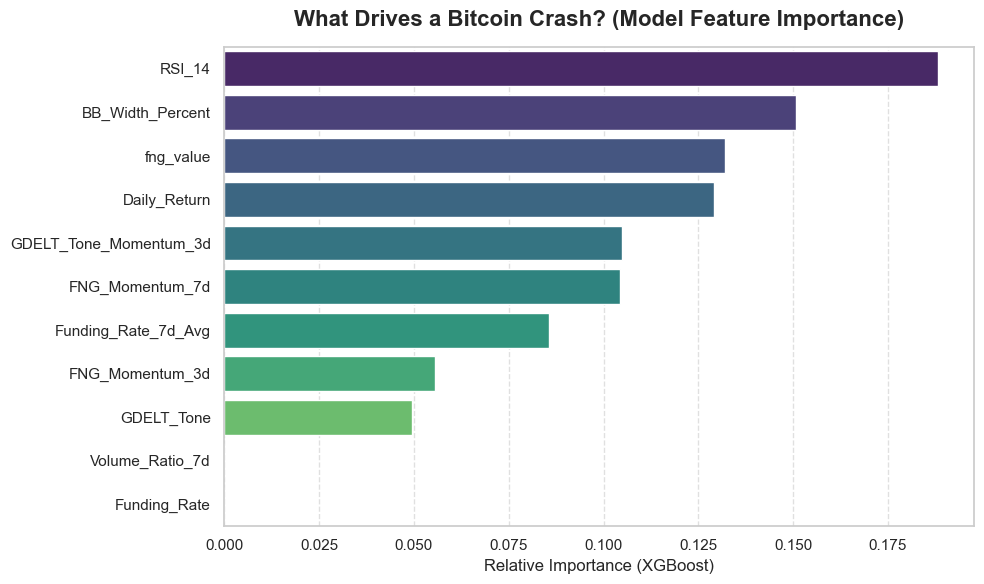

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature', legend=False)

plt.title('What Drives a Bitcoin Crash? (Model Feature Importance)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Relative Importance (XGBoost)', fontsize=12)
plt.ylabel('')

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig('phase5_feature_importance.png', dpi=300)
plt.show()

In [79]:
import numpy as np

# We use the test set prices and your best model's predictions
# Assuming 'split_idx', 'y_pred', and 'df' are in memory from Cell 11
test_prices = df['Close'].iloc[split_idx:].values
predictions = y_pred 

initial_capital = 10000.0  # Start with $10k
capital_history = []

# Starting positions
current_btc = initial_capital / test_prices[0]
current_cash = 0.0

for i in range(len(test_prices)):
    if predictions[i] == 1: 
        # CRASH PREDICTED: Sell BTC to USD
        if current_btc > 0:
            current_cash = current_btc * test_prices[i]
            current_btc = 0.0
    else: 
        # NORMAL DAY: Buy BTC with USD
        if current_cash > 0:
            current_btc = current_cash / test_prices[i]
            current_cash = 0.0
            
    # Calculate total portfolio value for the day
    daily_value = current_cash + (current_btc * test_prices[i])
    capital_history.append(daily_value)

# Final Calculations
final_ai_value = capital_history[-1]
ai_roi = ((final_ai_value - initial_capital) / initial_capital) * 100

buy_and_hold_value = (initial_capital / test_prices[0]) * test_prices[-1]
hodl_roi = ((buy_and_hold_value - initial_capital) / initial_capital) * 100

print("==========================================")
print("      SIMULATED TRADING BACKTEST          ")
print("==========================================")
print(f"Starting Capital:       ${initial_capital:,.2f}")
print(f"Final Portfolio Value:  ${final_ai_value:,.2f}")
print(f"AI Strategy ROI:        {ai_roi:.2f}%")
print("------------------------------------------")
print(f"Buy & Hold Final Value: ${buy_and_hold_value:,.2f}")
print(f"Buy & Hold ROI:         {hodl_roi:.2f}%")
print("==========================================")

if ai_roi > hodl_roi:
    print(f"Result: The AI Model outperformed Buy & Hold by {(ai_roi - hodl_roi):.2f}%!")
else:
    print(f"Result: Buy & Hold outperformed the AI Model by {(hodl_roi - ai_roi):.2f}%!")

      SIMULATED TRADING BACKTEST          
Starting Capital:       $10,000.00
Final Portfolio Value:  $8,662.74
AI Strategy ROI:        -13.37%
------------------------------------------
Buy & Hold Final Value: $6,537.25
Buy & Hold ROI:         -34.63%
Result: The AI Model outperformed Buy & Hold by 21.25%!


In [ ]:
import sys
import subprocess
import os

os.system('jupyter nbconvert --to html Bitcoin.ipynb')

subprocess.run([sys.executable, "-m", "pip", "install", "nbconvert"], capture_output=True)

cmd = f"{sys.executable} -m jupyter nbconvert --to html Bitcoin.ipynb"
result = subprocess.run(cmd, shell=True, capture_output=True, text=True)

print(result.stdout)
print(result.stderr)


[NbConvertApp] Converting notebook Bitcoin.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 772917 bytes to Bitcoin.html

